In [3]:
import torch 
# Install needed packages iff running in Google Colab
# import sys
# if "google.colab" in sys.modules:
#     !pip install bertviz torchinfo

2+2

4

*Many code components adapted from [Prof. Michael Linderman's lecture](https://middcs.github.io/data-science-notes/source/32-generative-nn.html)*: 

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
checkpoint = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
# Use slower eager attention to enable attention outputs
model = AutoModelForCausalLM.from_pretrained(checkpoint, attn_implementation="eager", output_attentions=True)
model.eval();  # Put model in evaluation mode

/Users/philchodrow/opt/anaconda3/envs/cs451/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5533.28it/s]


In [5]:
from matplotlib import pyplot as plt
import seaborn as sns

def _format_special_chars(tokens):
    """Return sequence of tokens with special characters replaced"""
    return [t.replace('Ġ', ' ') for t in tokens]

def plot_attention(attentions, inputs, layer=0, head=0, **kwargs):
    """Plot the attentions attention weights, labeled with tokens, for a specific layer and head."""
    tokens = _format_special_chars(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))
    att = attentions[layer][0, head, :, :].detach().numpy()
    ax = sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, **kwargs)
    ax.set(title=f"Attentions Layer {layer} Head {head}", xlabel="Attends to", ylabel="Query")
    return ax

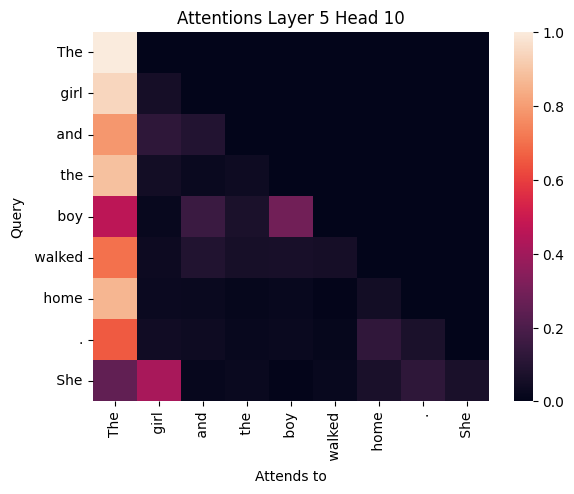

In [ ]:
inputs = tokenizer("The girl and the boy walked home. She", return_tensors="pt")
output = model(**inputs)
# output.attentions is (layers) length tuple of (batch_size, num_heads, seq_len, seq_len) tensors
# containing attention weights after the attention softmax, used to compute the weighted average in
# self-attention heads.
plot_attention(output.attentions, inputs, layer=5, head=10)


In [ ]:
output.attentions[5][0, 10, 8, :].detach()

In [ ]:
inputs = tokenizer("The girl and the boy walked home. He", return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10)
plt.show()

## Theory of the Attention Mechanism

### Scaled Dot-Product Attention

### Causal Masking

### Positional Encoding

## Attention Layers in GPT2